# Exploratory data analysis — a visual tour

Everything up to this point produced tables and printed numbers. This notebook
turns the same intermediate files into pictures: the shape of the count matrix,
the spread of sequencing depth, what the metadata covers, how complete the
cleaned variables are, how the sample count shrinks through quality control, and
what the abundance transforms do.

It reads only files already written by the earlier notebooks (`data/interim/`,
`data/processed/`, `audit/`, `reports/`) plus the three raw metadata files, and
writes one PNG per figure to `reports/figures/`. The plotting code lives in
`src/plots.py`; the cells here just load data and call it.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

%matplotlib inline

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import plots
from src import cohorts as coh

plots.apply_style()

INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

params = yaml.safe_load(open(ROOT / "config" / "params.yaml"))
DEPTH_THRESHOLD = params["qc"]["depth_threshold"]
MIN_PER_SIDE = params["qc"]["min_cases_per_project"]
print(f"depth threshold: {DEPTH_THRESHOLD:,} reads   min cases/controls per study: {MIN_PER_SIDE}")

depth threshold: 10,000 reads   min cases/controls per study: 10


## 1. The count matrix

### How many genera are in a sample

The table has 4,680 genus columns, but a single stool sample only contains a
small fraction of them. This histogram counts the non-zero columns per sample.
The bulk of samples sit around the median (dashed line) of roughly four to five
dozen genera — which is why the raw matrix is about 99% zeros and why the
transforms later restrict themselves to the genera that actually recur.

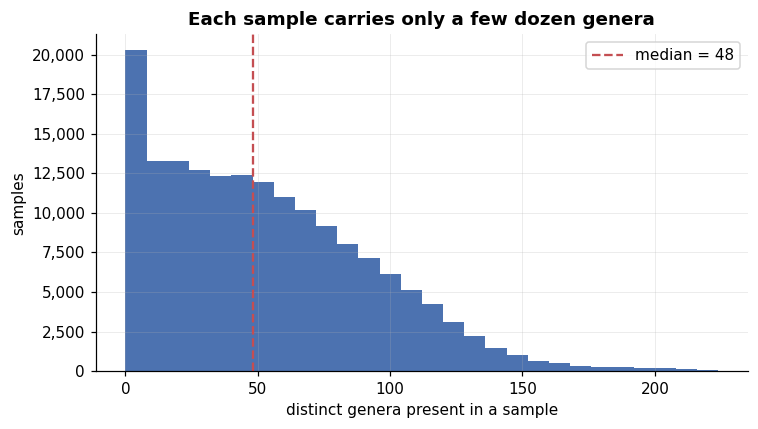

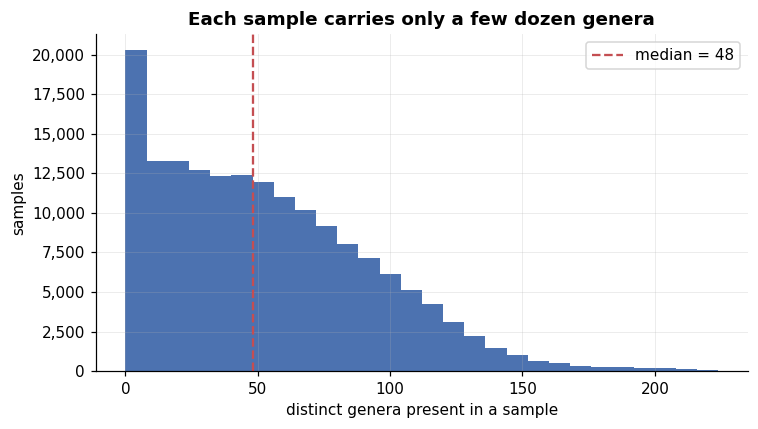

In [2]:
sample_depth = pd.read_parquet(INTERIM / "sample_depth.parquet")

fig = plots.plot_taxa_per_sample(sample_depth)
fig.savefig(FIGURES / "eda_01_taxa_per_sample.png")
fig

### The prevalence curve

Here every genus is ranked by the fraction of samples it appears in, highest
first, on a log scale. The shape is the whole story: a very small "core" of
genera turns up in most samples, then the curve falls away into a long tail of
genera seen in only a handful. The dotted lines mark prevalence cut-offs — the
pipeline keeps the ~419 genera above 1% for the log-ratio transform and modelling,
because the rarer ones carry almost no usable signal and destabilise the maths.

*(This cell scans the full 168,464 × 4,680 matrix in row batches — about 20 seconds.)*

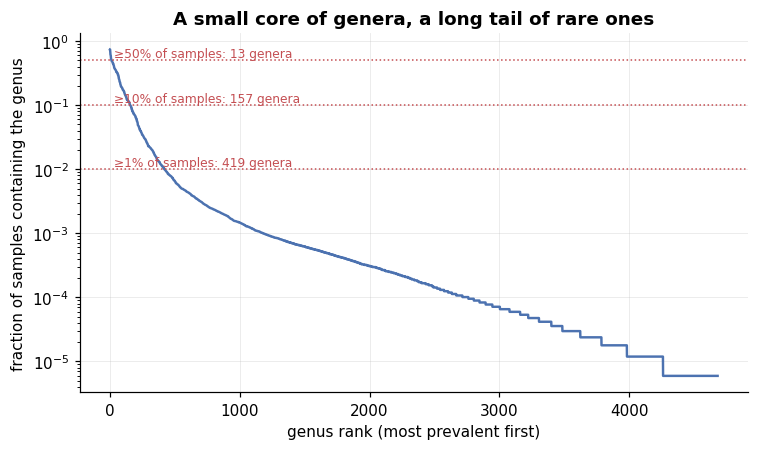

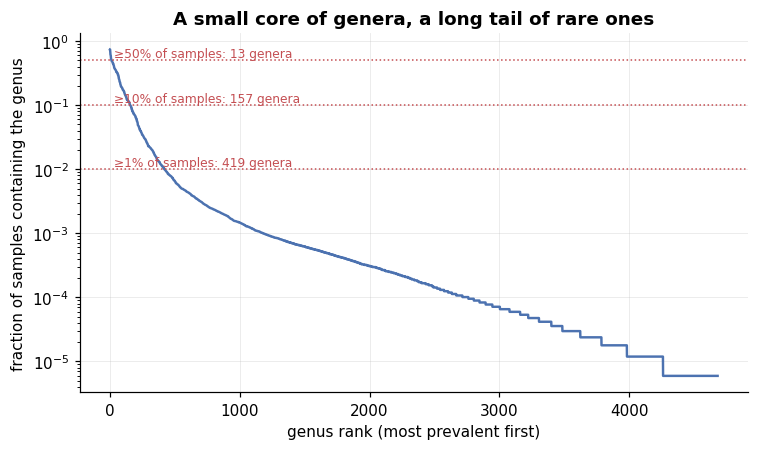

In [3]:
prevalence = plots.taxon_prevalence(INTERIM / "taxa_full.parquet", n_rows=len(sample_depth))

fig = plots.plot_prevalence_curve(prevalence)
fig.savefig(FIGURES / "eda_02_prevalence_curve.png")
fig

### What kind of organisms the columns are

A quick check that the table is what we think it is: the columns are
overwhelmingly bacterial genera, with a small set of Archaea and two columns that
don't resolve to a kingdom. Note the log scale on the x-axis.

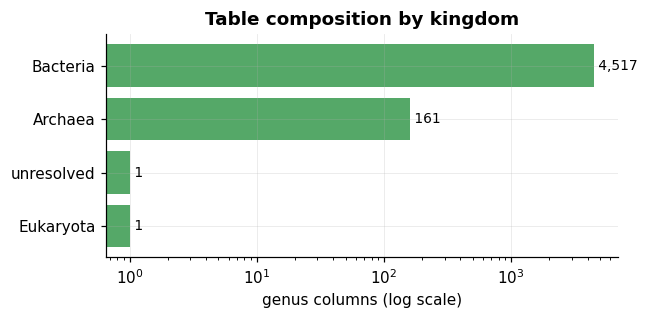

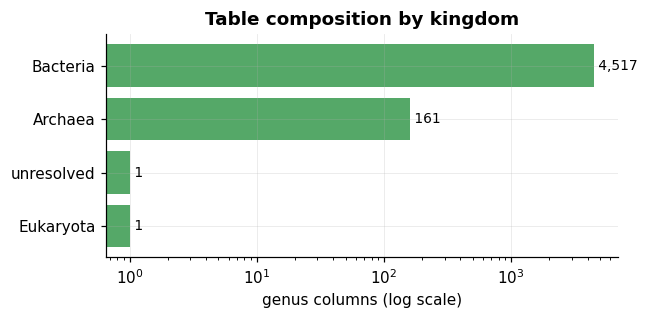

In [4]:
taxon_table = pd.read_parquet(INTERIM / "taxon_table.parquet")

fig = plots.plot_kingdom_split(taxon_table)
fig.savefig(FIGURES / "eda_03_kingdom_split.png")
fig

## 2. Sequencing depth

### How deep the samples were sequenced

Read depth is the number of gene fragments recovered from a sample. It varies
enormously — from a single read to nearly ten million — so the axis is log
scaled. Samples to the left of the dashed line have too few reads to estimate
composition reliably and are removed in quality control; the title reports how
many that is.

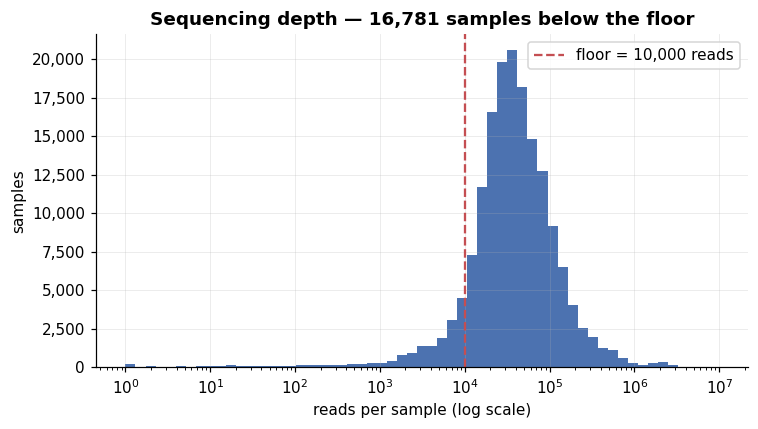

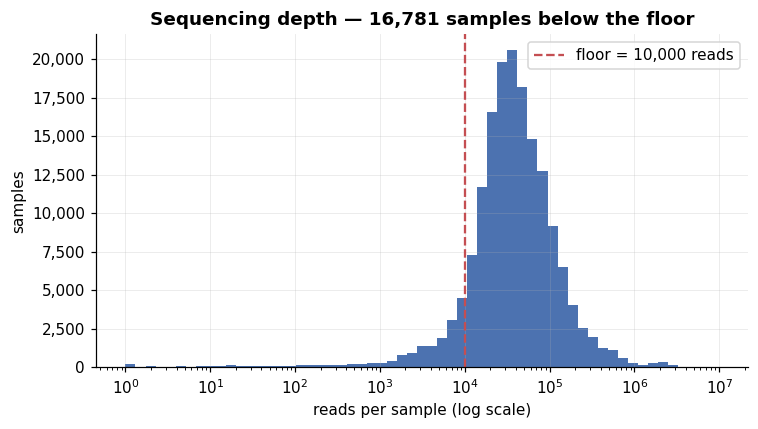

In [5]:
fig = plots.plot_depth_distribution(sample_depth, DEPTH_THRESHOLD)
fig.savefig(FIGURES / "eda_04_depth_distribution.png")
fig

### Depth drives apparent richness

Each hexagon is a bin of samples, coloured by how many fall in it. The number of
genera observed rises steeply with depth and then flattens. Two consequences:
depth has to be treated as a confounder whenever richness is compared between
groups, and the minimum-depth rule is a floor to exclude the clearly
under-sequenced tail, not a claim that richness is fully saturated above it.

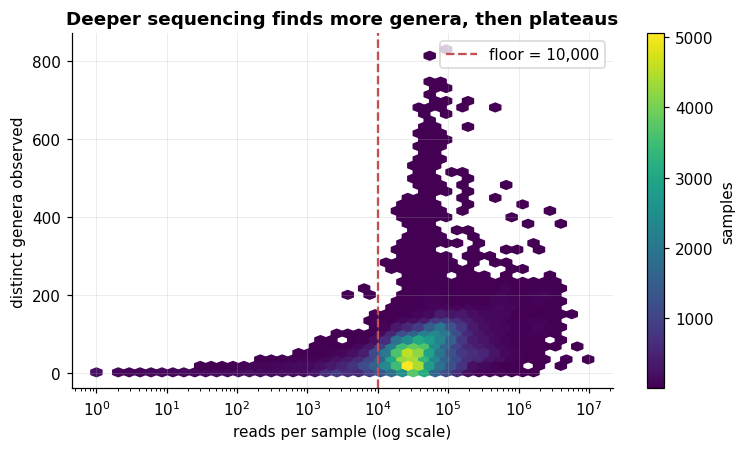

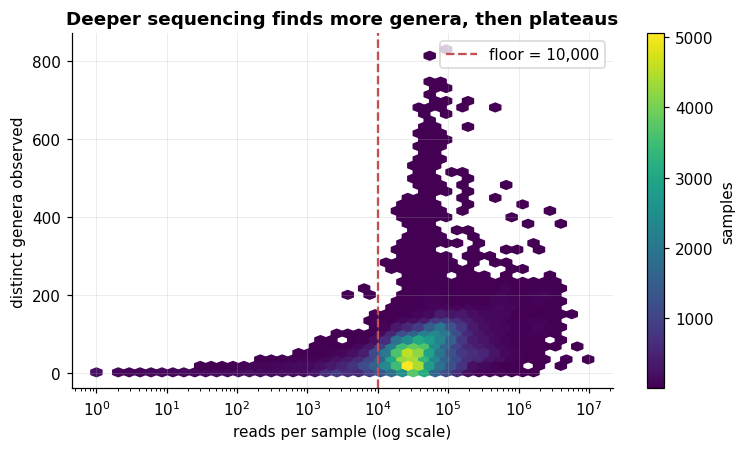

In [6]:
fig = plots.plot_depth_vs_richness(sample_depth, DEPTH_THRESHOLD)
fig.savefig(FIGURES / "eda_05_depth_vs_richness.png")
fig

## 3. The metadata landscape

### Which metadata fields are actually populated

The compendium's per-sample metadata uses 2,608 distinct field names, but that
number is misleading — most are used by a single study. This chart shows the
few dozen fields that are filled in for the most samples. These are the fields
worth the effort of cleaning and merging; the long tail is left alone.

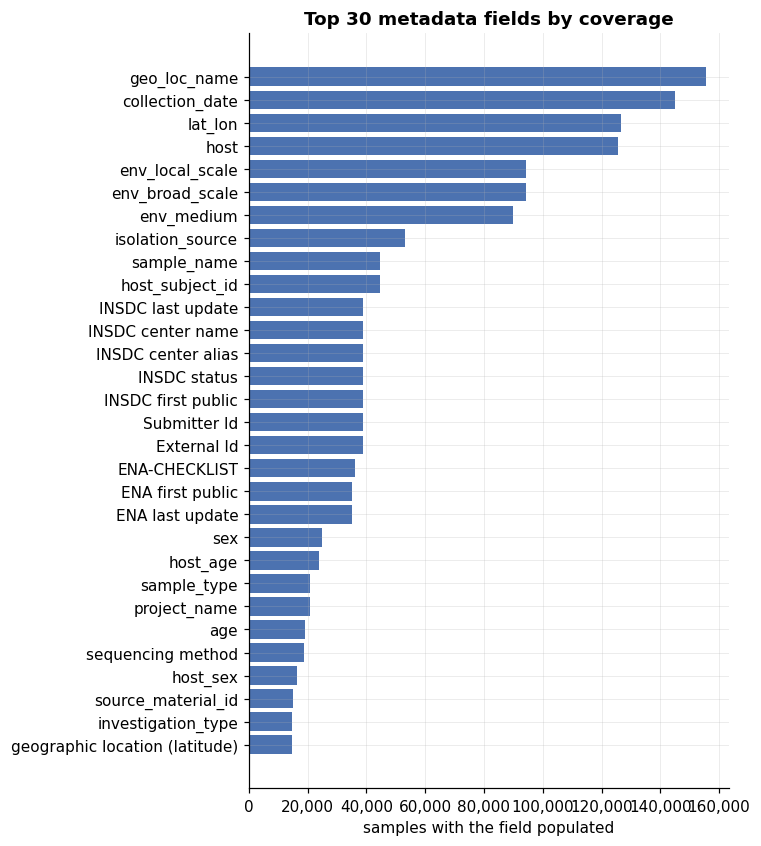

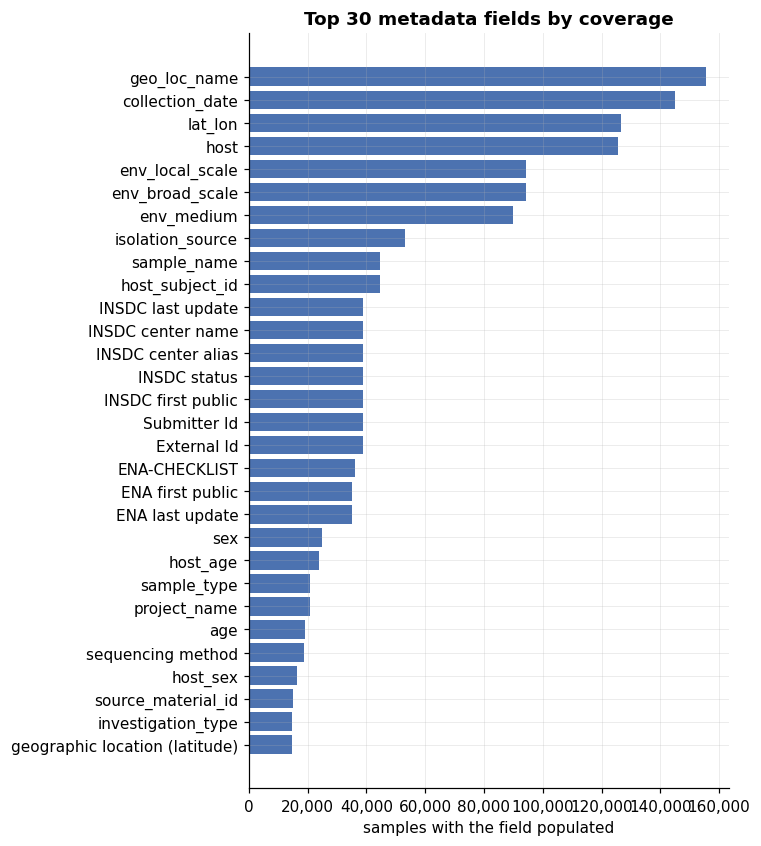

In [7]:
tag_summary = pd.read_csv(ROOT / "audit" / "tag_summary.csv")

fig = plots.plot_field_coverage(tag_summary, top=30)
fig.savefig(FIGURES / "eda_06_field_coverage.png")
fig

### How large the contributing studies are

482 studies contribute samples, and they are very unevenly sized (log x-axis): a
few large cohorts, a long tail of small ones. This matters for the analysis
design — a naive pooled comparison would be dominated by the biggest few studies,
which is part of why a within-study design is used alongside it.

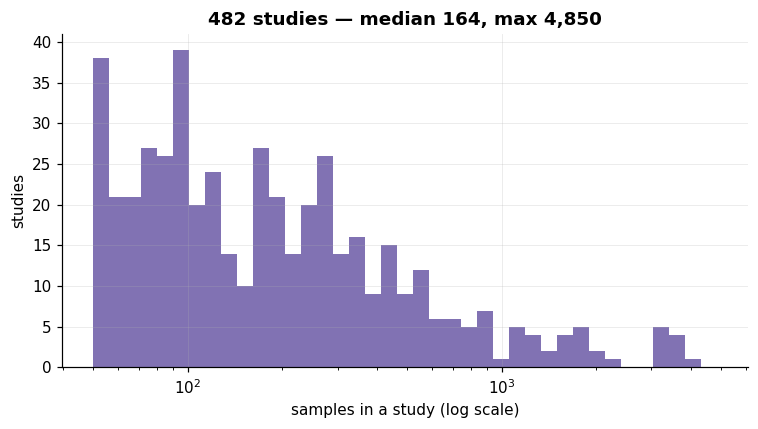

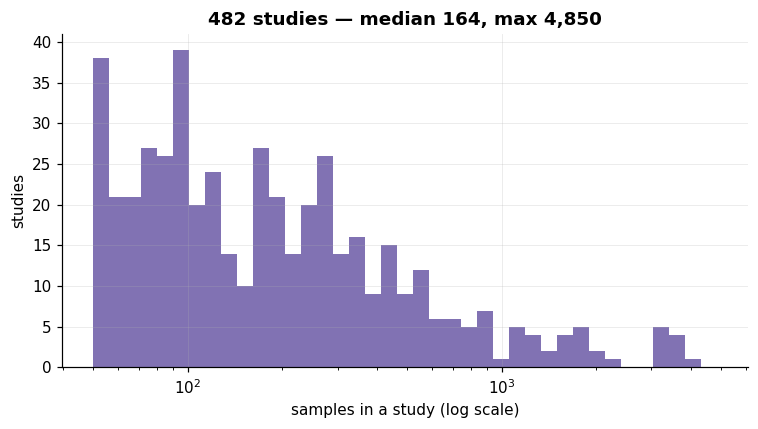

In [8]:
sample_metadata = pd.read_csv(ROOT / "Data" / "sample_metadata.tsv", sep="\t", dtype=str)

fig = plots.plot_samples_per_project(sample_metadata["project"].value_counts())
fig.savefig(FIGURES / "eda_07_samples_per_project.png")
fig

### Where the samples come from

Samples by world region, with the share of the total annotated on each bar. The
compendium is heavily weighted toward Europe and Northern America, and a sizeable
block has no usable country. Any statement about "the human gut microbiome" from
this data is really a statement about a mostly Western one — a limitation to
state plainly in the write-up.

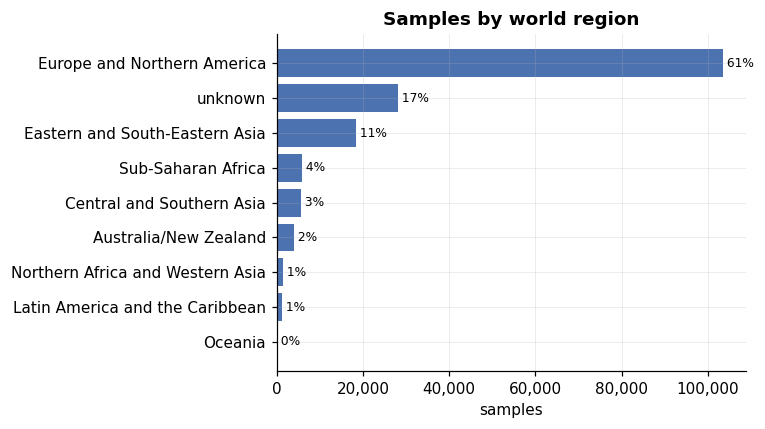

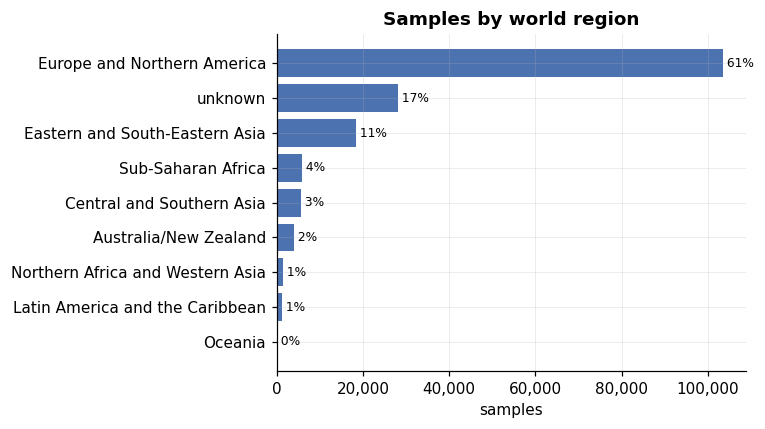

In [9]:
fig = plots.plot_geography(sample_metadata)
fig.savefig(FIGURES / "eda_08_geography.png")
fig

### Two knobs the lab turned

The left panel is the 16S region each study chose to sequence; the right is the
instrument that produced the reads. Neither is uniform, and both change the
numbers that come out even for identical input material. These are exactly the
technical factors the variance analysis has to account for before any
disease signal can be trusted.

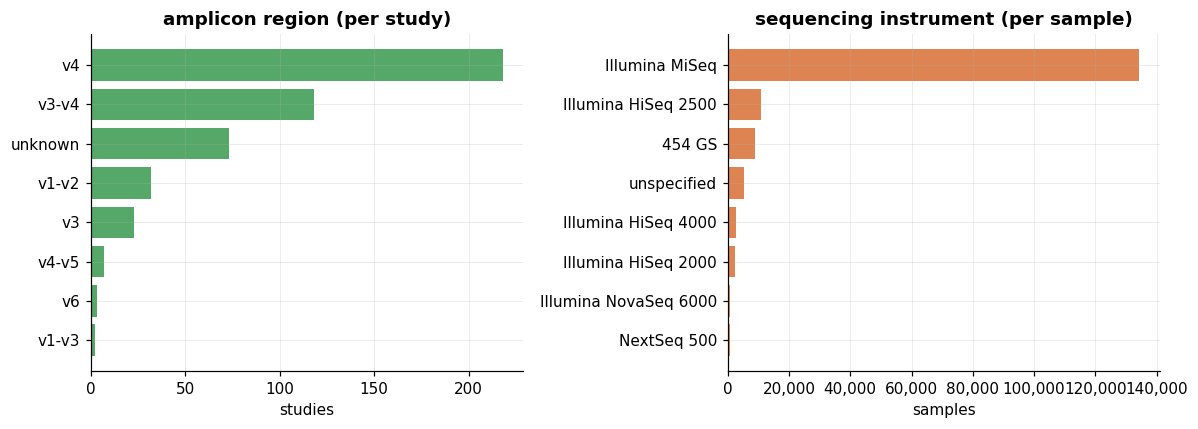

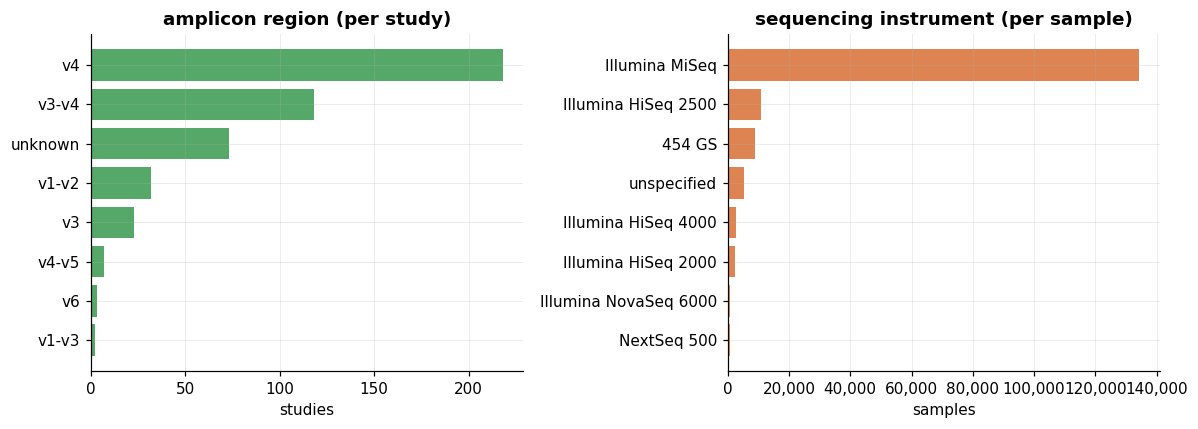

In [10]:
projects = pd.read_csv(ROOT / "Data" / "projects.csv", encoding="utf-8-sig", dtype=str)

fig = plots.plot_technical_factors(sample_metadata, projects)
fig.savefig(FIGURES / "eda_09_technical_factors.png")
fig

## 4. The harmonised variables

### Coverage after cleaning

For each cleaned variable, the percentage of the 168,464 samples that end up with
a value. The project-level technical fields (amplicon, kit, instrument, region)
are essentially complete because they are known for every study. The biological
variables are not: age, sex and BMI are recorded for a minority of samples, and a
usable disease label exists for about one in eight. This ceiling is what the
disease analysis has to work within.

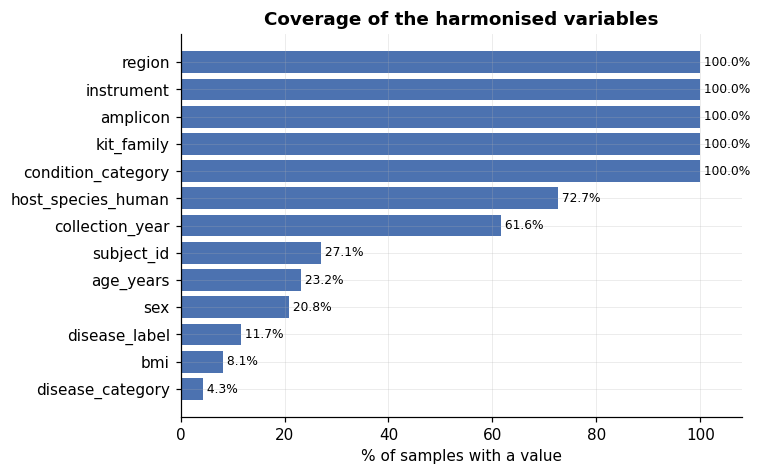

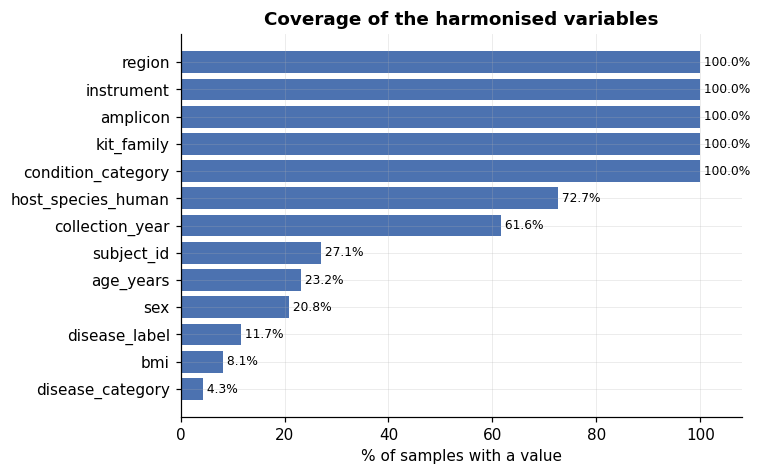

In [11]:
harmonized = pd.read_parquet(INTERIM / "samples_harmonized.parquet")

CONCEPTS = [
    "age_years", "sex", "bmi", "host_species_human", "collection_year",
    "subject_id", "disease_label", "disease_category",
    "condition_category", "kit_family", "amplicon", "instrument", "region",
]

fig = plots.plot_harmonized_coverage(harmonized, CONCEPTS)
fig.savefig(FIGURES / "eda_10_harmonized_coverage.png")
fig

### Do the gaps line up

Each cell is the correlation between "variable A is missing" and "variable B is
missing" across all samples. Strong positive blocks mean the missingness is
structural — whole studies simply didn't record that group of fields — rather
than scattered at random. That distinction matters: structural gaps can't be
imputed away, and they tell you which analyses are limited to which subset of
studies.

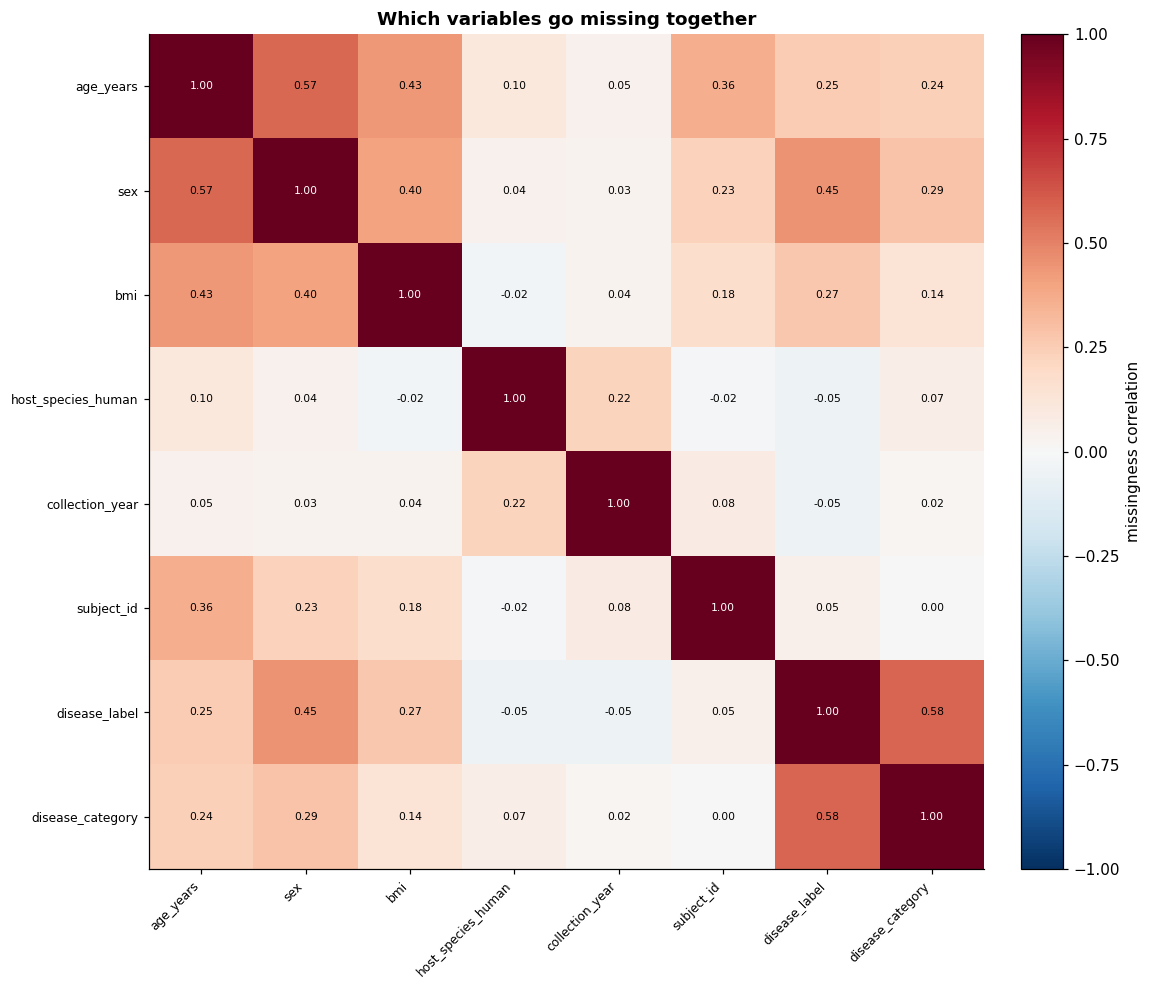

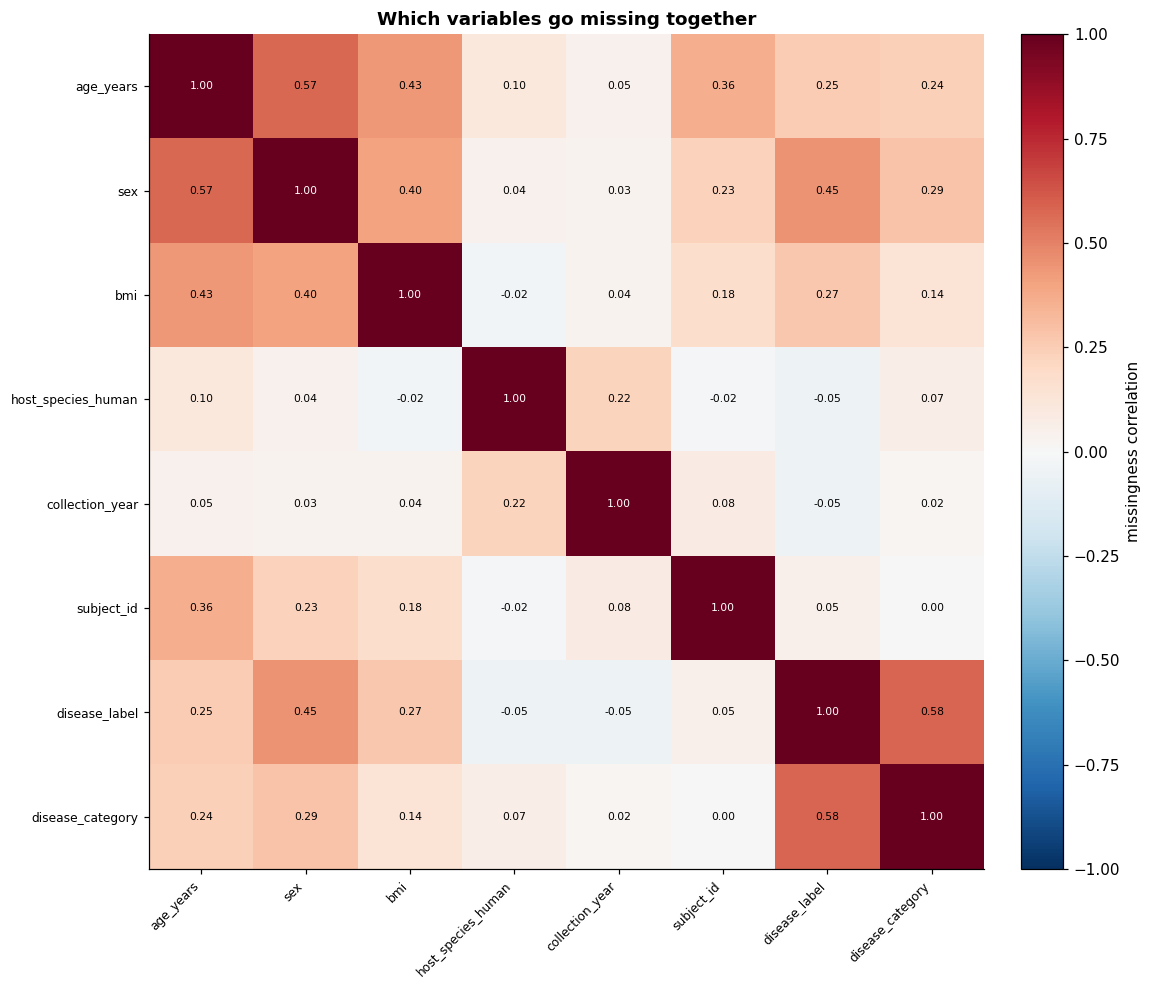

In [12]:
fig = plots.plot_comissingness(harmonized, CONCEPTS)
fig.savefig(FIGURES / "eda_11_comissingness.png")
fig

### Parsed age, and how trustworthy it is

Age is written a dozen different ways in the source data. The parser records not
just a number but how it got there: `exact` (a plain value with an explicit
unit), `range` (a band, midpoint taken), `bound` (an open-ended value like
"≥100"), and `inferred` (the unit years-vs-months was deduced from the study
population). The stack shows `inferred` is the largest slice, so age-based
results should lean on the `exact` subset for anything load-bearing.

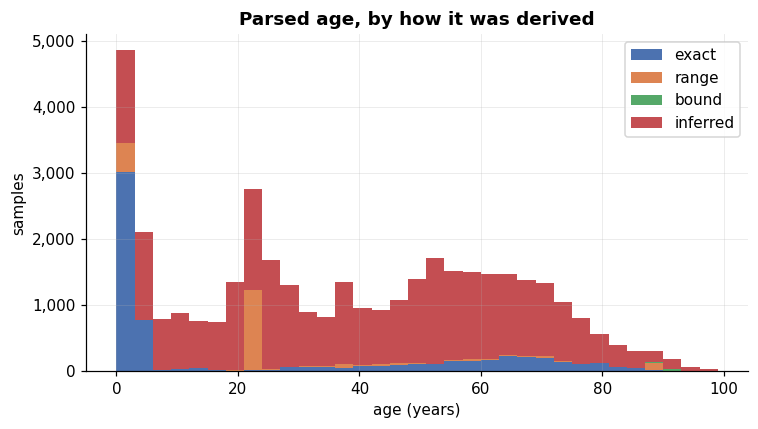

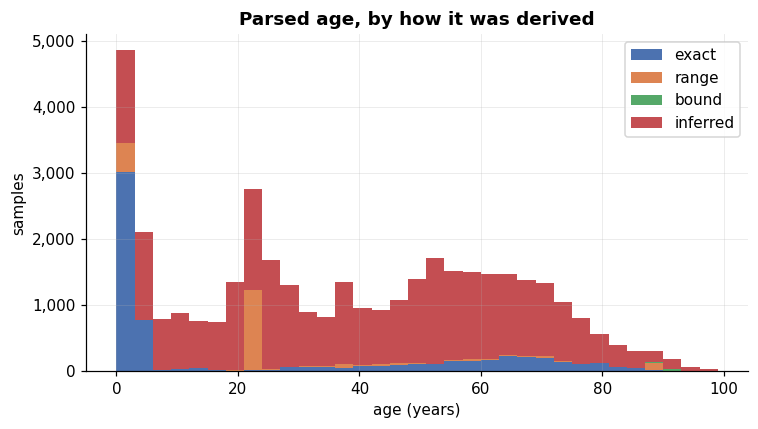

In [13]:
fig = plots.plot_age_distribution(harmonized)
fig.savefig(FIGURES / "eda_12_age_distribution.png")
fig

## 5. Quality filtering and the cohorts

### From every sample down to the working set

The left panel is the exclusion sequence: start from all 168,464 samples, then
drop confirmed non-human hosts, then anything that isn't a pure stool sample,
then anything below the depth floor. The right panel is the three labelled
cohorts built from what survives — the pooled labelled set, the within-study
case/control set, and the healthy-only baseline. The drop at the non-stool step
is the large one, and it is real: many studies deposited mixed body sites under
one label.

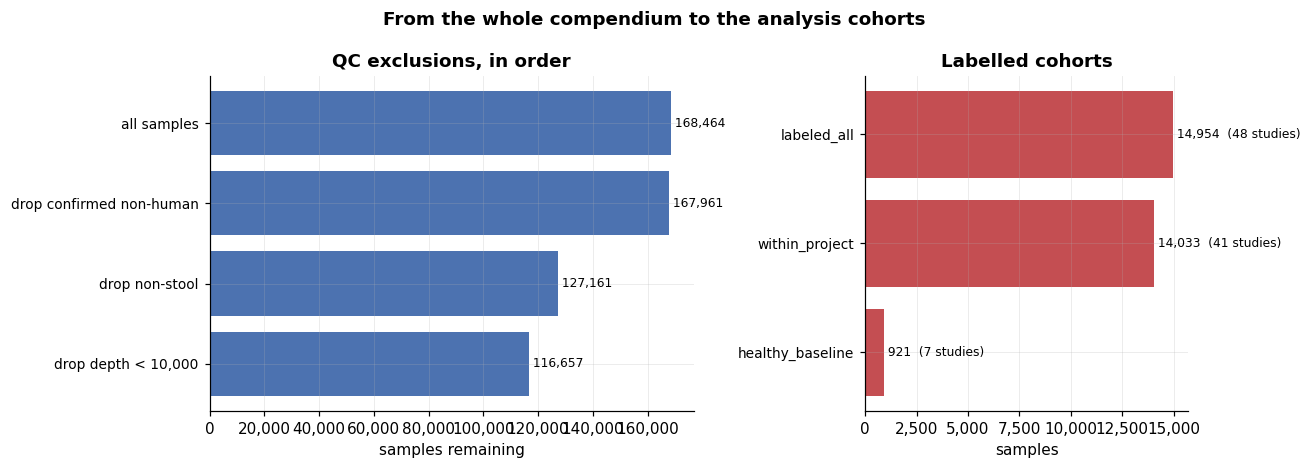

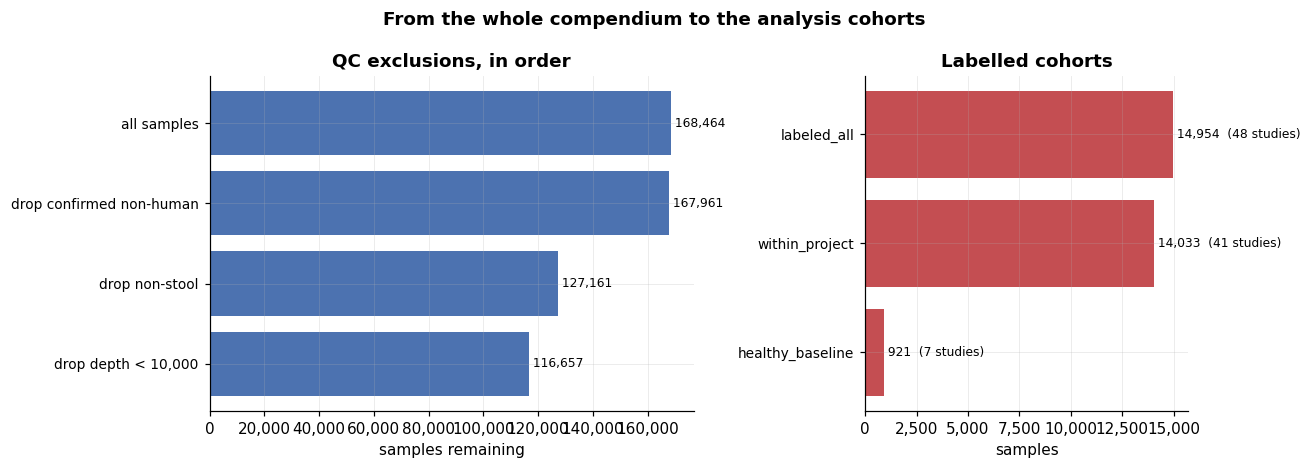

In [14]:
qc_df, flow = coh.apply_qc_filters(harmonized, sample_depth, DEPTH_THRESHOLD)

cohort_sizes = {}
for name in ["labeled_all", "within_project", "healthy_baseline"]:
    c = pd.read_parquet(PROCESSED / f"cohort_{name}.parquet")
    cohort_sizes[name] = (len(c), c["project"].nunique())

fig = plots.plot_qc_funnel(flow, cohort_sizes)
fig.savefig(FIGURES / "eda_13_qc_funnel.png")
fig

### Which studies can actually support a comparison

Every study that has both patients and healthy controls after quality control,
controls to the left and cases to the right, sorted by size. The dashed lines are
the minimum each side needs for that study to enter a within-study comparison.
Studies whose bars don't clear both lines are under-powered on their own — this
chart is the one to look at before deciding which studies feed the
meta-analysis.

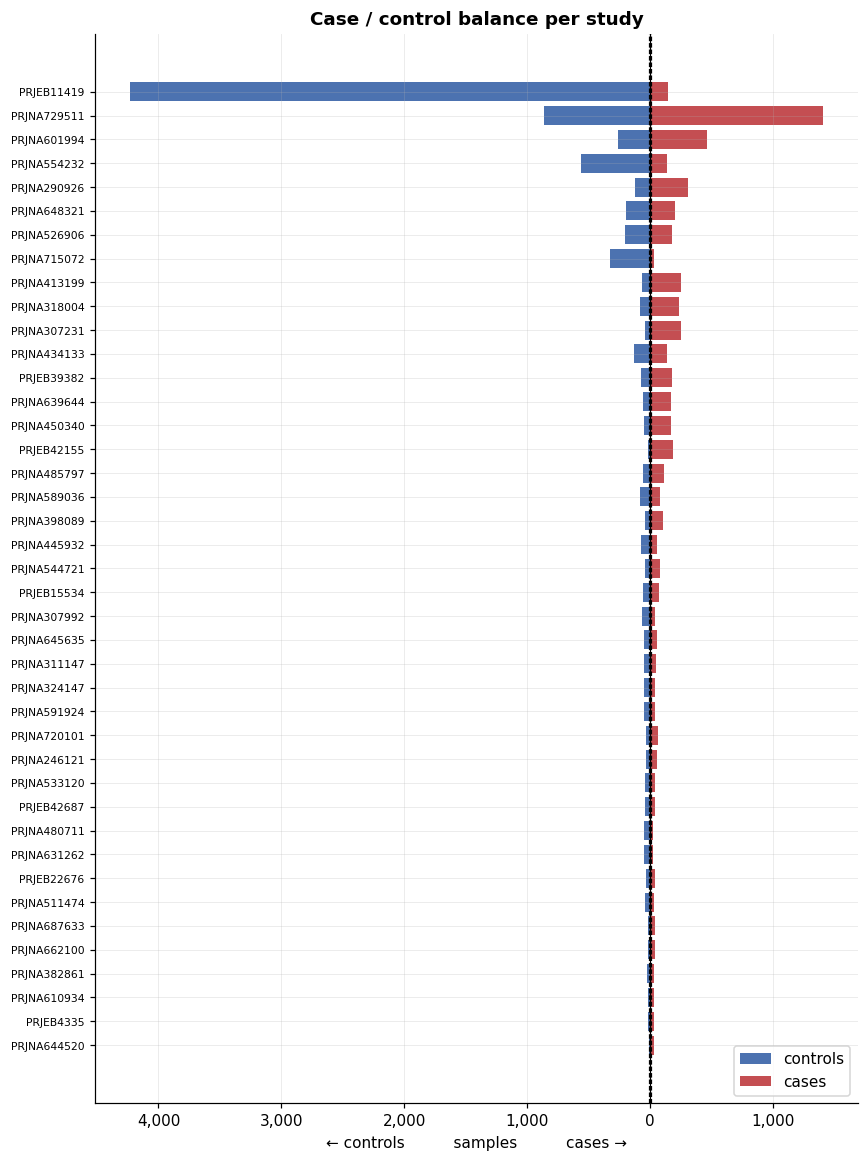

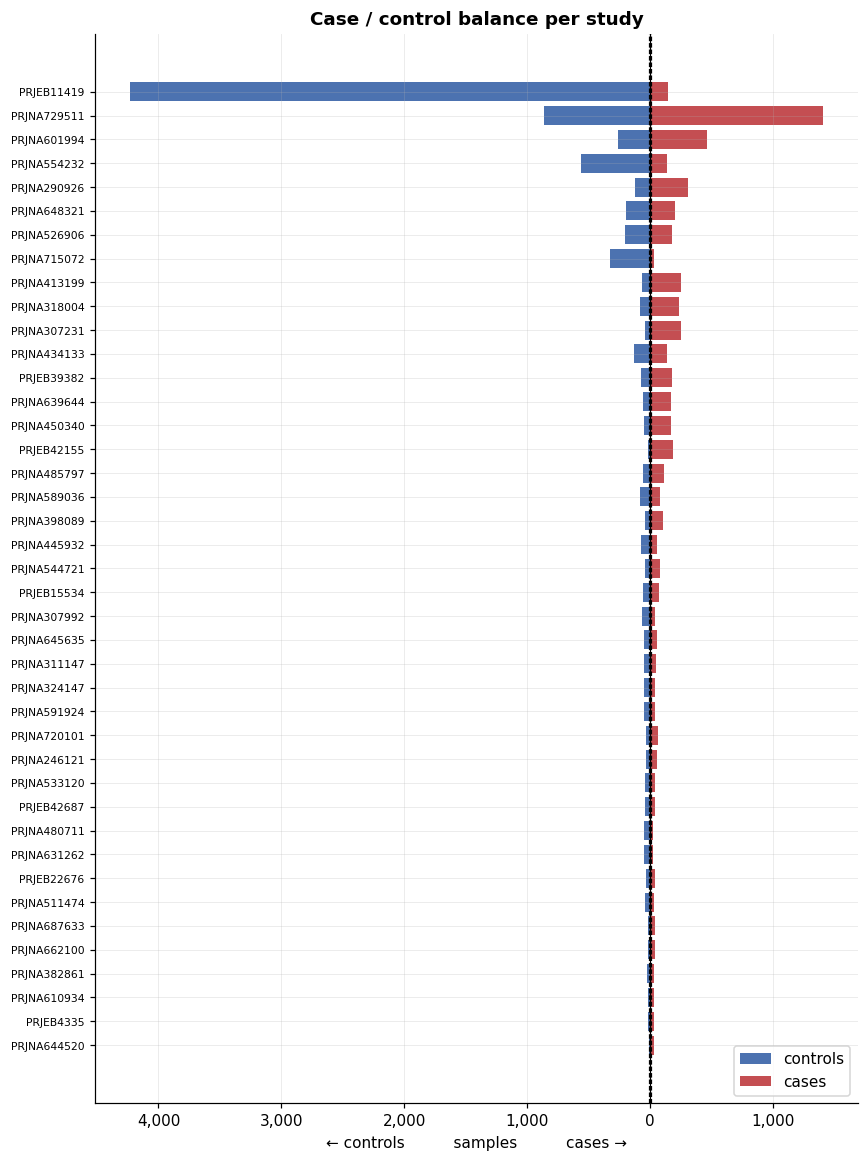

In [15]:
project_summary = pd.read_csv(ROOT / "reports" / "project_summary.csv")

fig = plots.plot_project_case_control(project_summary, min_per_side=MIN_PER_SIDE)
fig.savefig(FIGURES / "eda_14_project_case_control.png")
fig

## 6. Putting counts on a comparable scale

### What the average gut looks like

Mean relative abundance of the most abundant genera, across every quality-passed
sample. A dozen or so genera account for the bulk of the reads; this is the
backdrop against which any disease-associated shift has to stand out.

*(This cell scans `abund_relative.parquet` in row batches — about 20 seconds.)*

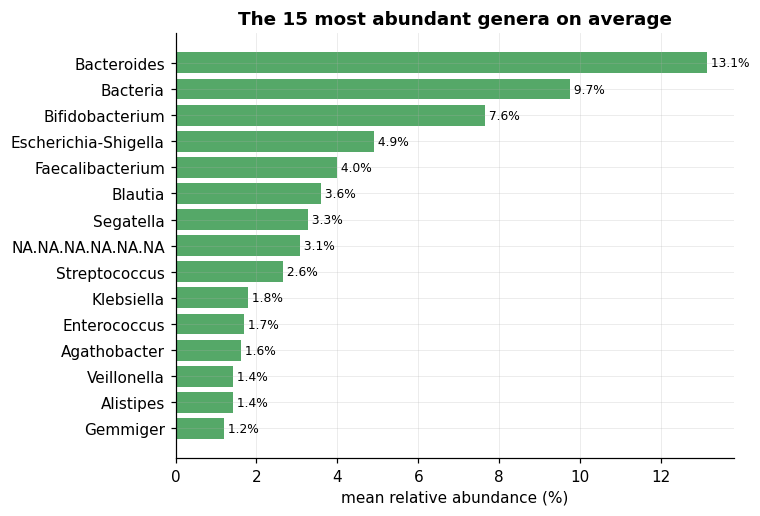

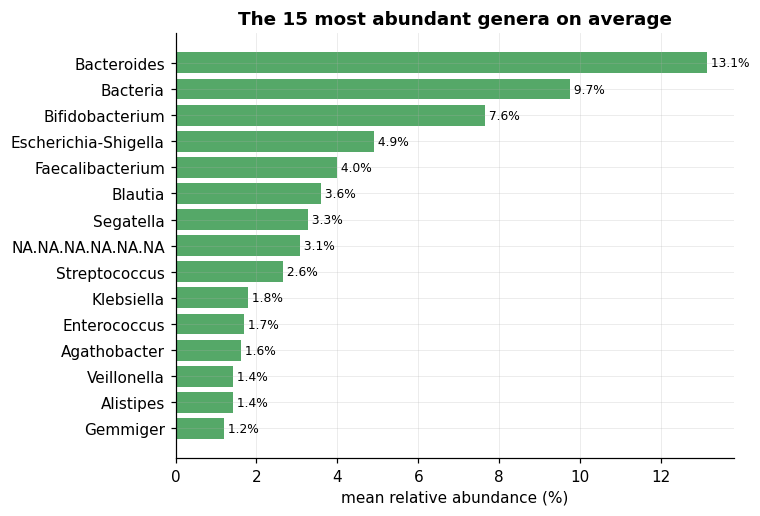

In [16]:
mean_rel = plots.mean_relative_abundance(PROCESSED / "abund_relative.parquet")

fig = plots.plot_top_genera(mean_rel, top=15)
fig.savefig(FIGURES / "eda_15_top_genera.png")
fig

### Why the log-ratio transform

The same handful of common genera, before and after the centred-log-ratio (CLR)
transform. On the left, relative abundance: bounded at zero, heavily skewed, with
a spike of exact zeros dropped from the plot. On the right, CLR: roughly
symmetric and unbounded, which is the form the differential-abundance models
expect. This is the visual argument for not testing on raw proportions.

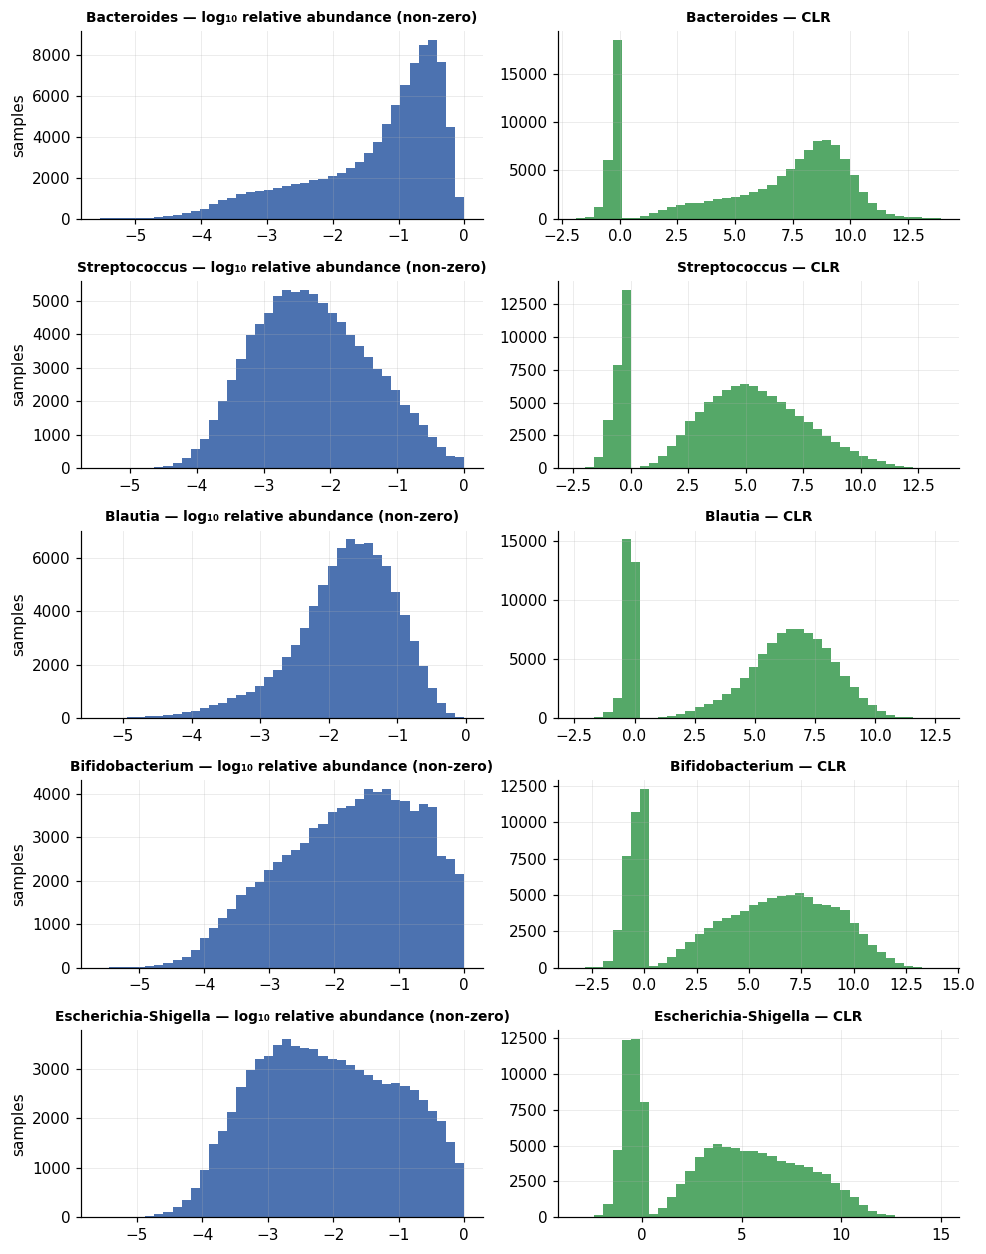

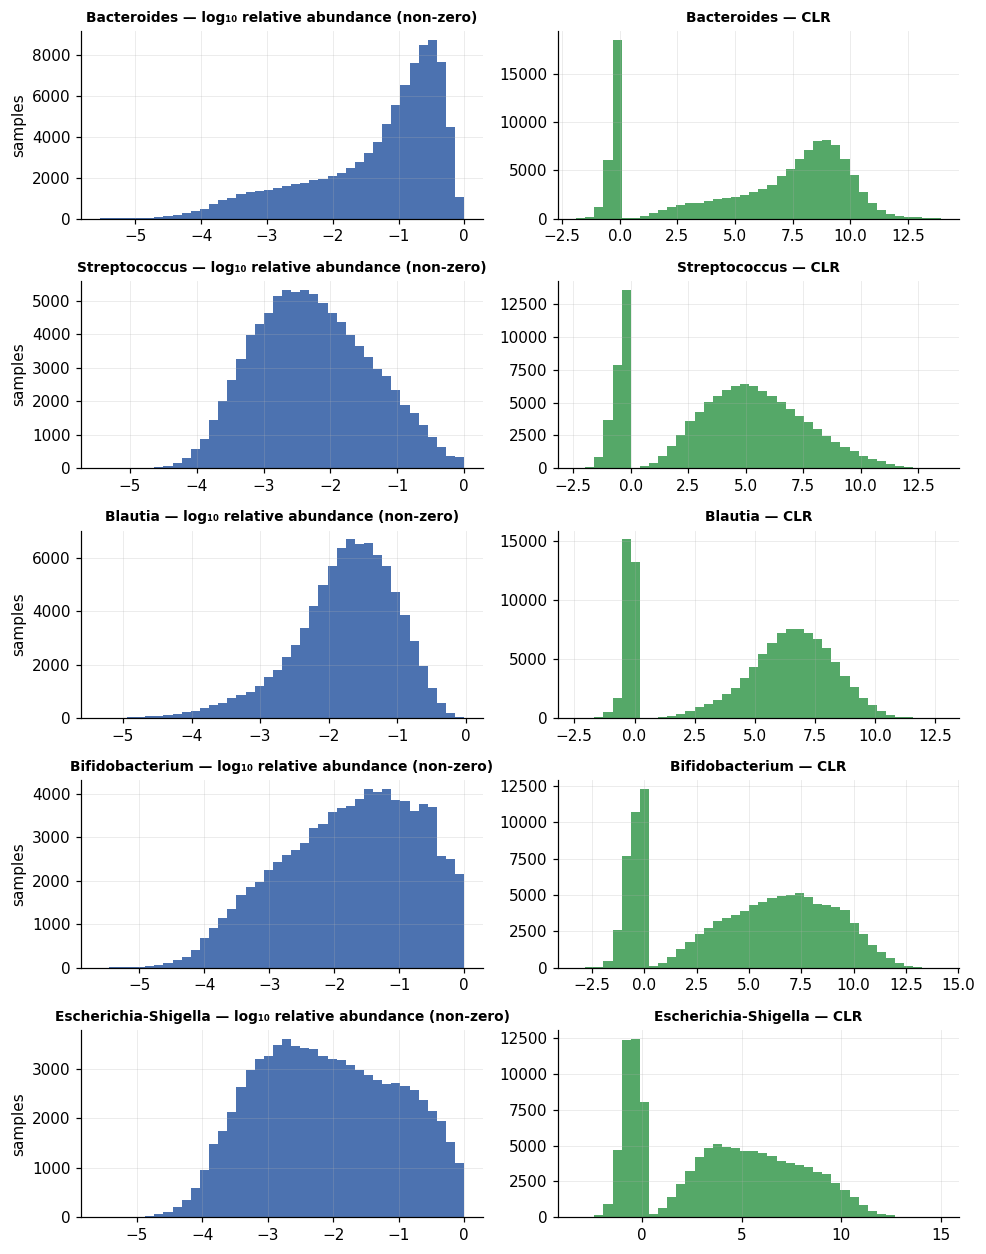

In [17]:
example_genera = list(prevalence.sort_values(ascending=False).head(5).index)

fig = plots.plot_clr_vs_relative(
    PROCESSED / "abund_relative.parquet",
    PROCESSED / "abund_clr.parquet",
    example_genera,
)
fig.savefig(FIGURES / "eda_16_clr_vs_relative.png")
fig

## What this covers, and what it doesn't

**Covered:** the sparsity and prevalence structure of the count matrix, the
depth distribution and its effect on richness, metadata coverage and the Western
skew, technical heterogeneity (amplicon and instrument), completeness and
co-missingness of the cleaned variables, the quality-control funnel and cohort
sizes, per-study case/control balance, the average community composition, and
the effect of the CLR transform.

**Not covered here, and worth adding later:** an ordination (PCoA or UMAP) of the
samples coloured by study versus by disease — the headline picture for the
technical-variance question — and, once differential abundance has run, a
concordance plot of the within-study versus pooled effect sizes. Both need
outputs that don't exist yet.

Every figure is written to `reports/figures/eda_*.png`.